In [ ]:
import numpy as np, matplotlib.pyplot as plt, pandas as pd, seaborn as sns
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [ ]:
print(train.shape, test.shape)
print("\n")
print('Datatypes of the columns:- ')
print(train.dtypes)
print("\n")
print('Number of null values in the columns:- ')
print(train.isnull().sum())

(77299, 11) (41778, 10)


Datatypes of the columns:- 
Index              int64
geohash           object
day                int64
timestamp         object
demand           float64
RoadType          object
NumberofLanes      int64
LargeVehicles     object
Landmarks         object
Temperature      float64
Weather           object
dtype: object


Number of null values in the columns:- 
Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64


In [ ]:
#Handling null values

# Mode per geohash group
road_mode = train.groupby("geohash")["RoadType"].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
global_road_mode = train["RoadType"].mode()[0]

def fill_roadtype(row, mode_map, global_mode):
    if pd.isna(row["RoadType"]):
        return mode_map.get(row["geohash"], global_mode)
    return row["RoadType"]

for df in [train, test]:
    df["RoadType"] = df.apply(fill_roadtype, axis=1, mode_map=road_mode, global_mode=global_road_mode)


# Median per (geohash, timestamp) group — fit on train only
temp_map = train.groupby(["geohash", "timestamp"])["Temperature"].median()
geo_temp_map = train.groupby("geohash")["Temperature"].median()
global_temp = train["Temperature"].median()

def fill_temp(row):
    if pd.isna(row["Temperature"]):
        val = temp_map.get((row["geohash"], row["timestamp"]), np.nan)
        if pd.isna(val):
            val = geo_temp_map.get(row["geohash"], global_temp)
        return val
    return row["Temperature"]

for df in [train, test]:
    df["Temperature"] = df.apply(fill_temp, axis=1)


# Mode per (geohash, day) group — fit on train only
weather_map = train.groupby(["geohash", "day"])["Weather"].agg(
    lambda x: x.mode()[0] if not x.mode().empty else np.nan
)
global_weather = train["Weather"].mode()[0]

def fill_weather(row):
    if pd.isna(row["Weather"]):
        val = weather_map.get((row["geohash"], row["day"]), np.nan)
        if pd.isna(val):
            val = global_weather
        return val
    return row["Weather"]

for df in [train, test]:
    df["Weather"] = df.apply(fill_weather, axis=1)


print("Train nulls after imputation:")
print(train[["RoadType", "Temperature", "Weather"]].isnull().sum())

print("\nTest nulls after imputation:")
print(test[["RoadType", "Temperature", "Weather"]].isnull().sum())

Train nulls after imputation:
RoadType       0
Temperature    0
Weather        0
dtype: int64

Test nulls after imputation:
RoadType       0
Temperature    0
Weather        0
dtype: int64


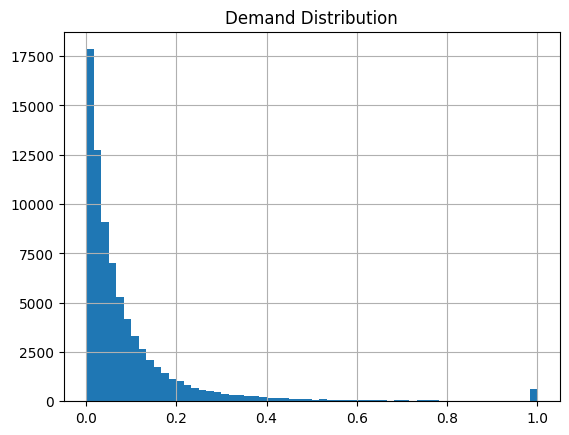

count    7.729900e+04
mean     9.394238e-02
std      1.421905e-01
min      6.245650e-07
25%      1.822723e-02
50%      4.775994e-02
75%      1.085951e-01
max      1.000000e+00
Name: demand, dtype: float64


In [ ]:
train['demand'].hist(bins=60); plt.title("Demand Distribution"); plt.show()
print(train['demand'].describe())

In [ ]:
#Box-Cox transform
from scipy import stats
# Fit on train only — save the lambda!
train["demand_transformed"], best_lambda = stats.boxcox(train["demand"] + 1e-6)
print(f"Lambda to save: {best_lambda}")       # 0.1374 — you MUST keep this
print(f"Skewness: {train['demand_transformed'].skew()}")  # ~0.013
# Use demand_transformed as your y (target) during model training
y_train = train["demand_transformed"]

Lambda to save: 0.13741298883328357
Skewness: 0.013426108957940181


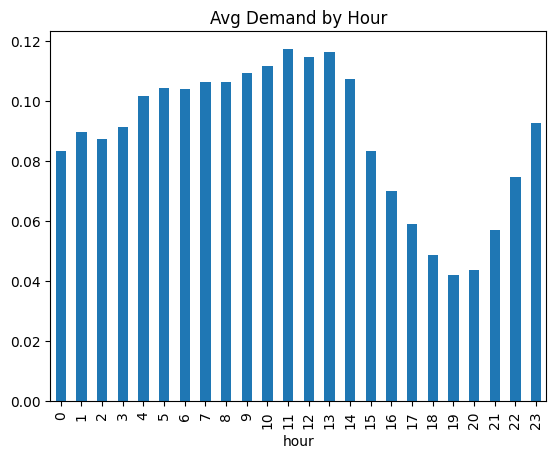

In [ ]:
train["hour"] = train["timestamp"].str.split(":").str[0].astype(int)
train.groupby("hour")["demand"].mean().plot(kind="bar", title="Avg Demand by Hour")
plt.show()

In [ ]:
#Peak demand hours
# Extract hour from timestamp
train["hour"] = train["timestamp"].str.split(":").str[0].astype(int)

# Average demand per hour across all days and locations
hourly_demand = train.groupby("hour")["demand"].mean().sort_values(ascending=False)
print("Top 5 peak demand hours:")
print(hourly_demand.head())
print(f"\nPeak hour: {hourly_demand.idxmax()}:00")
print(f"Lowest hour: {hourly_demand.idxmin()}:00")

Top 5 peak demand hours:
hour
11    0.117301
13    0.116308
12    0.114770
10    0.111602
9     0.109231
Name: demand, dtype: float64

Peak hour: 11:00
Lowest hour: 19:00


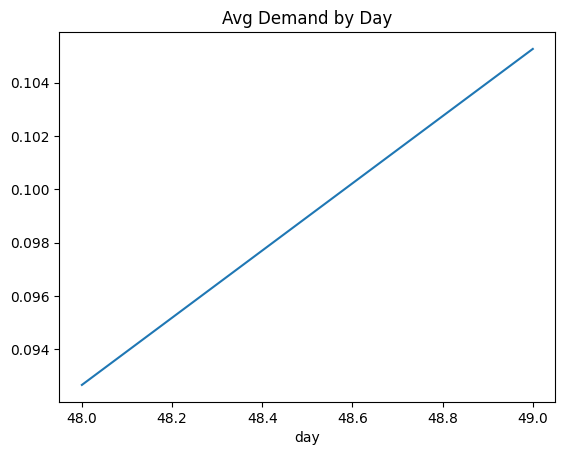

In [ ]:
train.groupby("day")["demand"].mean().plot(title="Avg Demand by Day"); plt.show()

In [ ]:
print(train.corr(numeric_only=True)["demand"].sort_values(ascending=False))

demand                1.000000
demand_transformed    0.779214
NumberofLanes         0.214148
day                   0.026807
Temperature           0.003143
Index                -0.001481
hour                 -0.037806
Name: demand, dtype: float64


In [ ]:
print("Unique geohashes: ", train["geohash"].nunique())
print(train.groupby("geohash")["demand"].mean().sort_values(ascending=False).head(10))

Unique geohashes:  1249
geohash
qp09d9    0.960715
qp09ft    0.868850
qp09e5    0.864989
qp09d8    0.669318
qp096x    0.665630
qp09d2    0.664722
qp09dc    0.661462
qp096r    0.650468
qp09d3    0.643498
qp03xx    0.631194
Name: demand, dtype: float64


In [ ]:
#Checking whether some geohashes have high demand and also the effect of weather on demand
geo_demand = train.groupby("geohash")["demand"].mean().sort_values(ascending=False)
print(geo_demand.head(10))
print("\n")
print(train.groupby("Weather")["demand"].mean().sort_values(ascending=False))

geohash
qp09d9    0.960715
qp09ft    0.868850
qp09e5    0.864989
qp09d8    0.669318
qp096x    0.665630
qp09d2    0.664722
qp09dc    0.661462
qp096r    0.650468
qp09d3    0.643498
qp03xx    0.631194
Name: demand, dtype: float64


Weather
Sunny    0.094418
Rainy    0.094407
Foggy    0.093331
Snowy    0.092552
Name: demand, dtype: float64


In [ ]:
#Extracting the features from timestamp, day and doing Cyclic encoding
train["hour"] = train["timestamp"].str.split(":").str[0].astype(int)
train["minute"] = train["timestamp"].str.split(":").str[1].astype(int)
train["time_slot"] = train["hour"] * 4 + train["minute"]

train["is_weekend"] = (train["day"] % 7).isin([5,6]).astype(int)
train["day_of_week"] = train["day"] % 7

train["hour_sin"] = np.sin(2 * np.pi * train["hour"]/24)
train["hour_cos"] = np.cos(2 * np.pi * train["hour"]/24)
train["slot_sin"] = np.sin(2 * np.pi * train["time_slot"] / 96)
train["slot_cos"] = np.cos(2 * np.pi * train["time_slot"] / 96)

In [ ]:
#Geohash Decoding
!pip install pygeohash
import pygeohash as gh
def decode_geo(g):
    try:
        lat, lng = gh.decode(g)
        return lat, lng
    except:
        return np.nan, np.nan

train["lat"], train["lng"] = zip(*train["geohash"].map(decode_geo))
test["lat"],  test["lng"]  = zip(*test["geohash"].map(decode_geo))

geo_stats = train.groupby("geohash")["demand"].agg(["mean","median","std","max"]).reset_index()
geo_stats.columns = ["geohash", "geo_demand_mean", "geo_demand_median", "geo_demand_std", "geo_demand_max"]

train = train.merge(geo_stats, on="geohash", how="left")
test  = test.merge(geo_stats,  on="geohash", how="left")

for col in ["geo_demand_mean", "geo_demand_median", "geo_demand_std", "geo_demand_max"]:
    test[col] = test[col].fillna(train["demand"].mean())

print("Train shape:", train.shape)
print("Test shape: ", test.shape)
print(train[["geohash", "lat", "lng", "geo_demand_mean"]].head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 4.0 MB/s eta 0:00:00
Train shape: (77299, 27)
Test shape:  (41778, 16)
  geohash       lat        lng  geo_demand_mean
0  qp02z1 -5.484924  90.664673         0.040048
1  qp02zt -5.462952  90.686646         0.208766
2  qp08bj -5.462952  90.708618         0.127931
3  qp08gt -5.462952  90.862427         0.014381
4  qp02zq -5.457458  90.675659         0.029300


In [ ]:
print("Train columns:", train.columns.tolist())
print("\nTest columns:", test.columns.tolist())

Train columns: ['Index', 'geohash', 'day', 'timestamp', 'demand', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather', 'demand_transformed', 'hour', 'minute', 'time_slot', 'is_weekend', 'day_of_week', 'hour_sin', 'hour_cos', 'slot_sin', 'slot_cos', 'lat', 'lng', 'geo_demand_mean', 'geo_demand_median', 'geo_demand_std', 'geo_demand_max']

Test columns: ['Index', 'geohash', 'day', 'timestamp', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather', 'lat', 'lng', 'geo_demand_mean', 'geo_demand_median', 'geo_demand_std', 'geo_demand_max']


In [ ]:
# Add time features to test (same way you did for train earlier)
test["hour"]       = test["timestamp"].str.split(":").str[0].astype(int)
test["minute"]     = test["timestamp"].str.split(":").str[1].astype(int)
test["time_slot"]  = test["hour"] * 4 + test["minute"] // 15
test["day_of_week"] = test["day"] % 7
test["is_weekend"] = test["day_of_week"].isin([5, 6]).astype(int)

test["hour_sin"]  = np.sin(2 * np.pi * test["hour"] / 24)
test["hour_cos"]  = np.cos(2 * np.pi * test["hour"] / 24)
test["slot_sin"]  = np.sin(2 * np.pi * test["time_slot"] / 96)
test["slot_cos"]  = np.cos(2 * np.pi * test["time_slot"] / 96)

print("Test columns now:", test.columns.tolist())

Test columns now: ['Index', 'geohash', 'day', 'timestamp', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather', 'lat', 'lng', 'geo_demand_mean', 'geo_demand_median', 'geo_demand_std', 'geo_demand_max', 'hour', 'minute', 'time_slot', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'slot_sin', 'slot_cos']


In [ ]:
#Demand on the basis of both time and location

# Drop if already exists (safe to run multiple times now)
cols_to_drop = ["geo_hour_demand", "geo_slot_demand"]
train = train.drop(columns=[c for c in cols_to_drop if c in train.columns])
test  = test.drop(columns=[c for c in cols_to_drop if c in test.columns])

# Part 1 — geo x hour (average demand per location per hour)
geo_hour = train.groupby(["geohash", "hour"])["demand"].mean().reset_index()
geo_hour.columns = ["geohash", "hour", "geo_hour_demand"]

train = train.merge(geo_hour, on=["geohash", "hour"], how="left")
test  = test.merge(geo_hour,  on=["geohash", "hour"], how="left")

# Fix FutureWarning — replace inplace with direct assignment
train["geo_hour_demand"] = train["geo_hour_demand"].fillna(train["geo_demand_mean"])
test["geo_hour_demand"]  = test["geo_hour_demand"].fillna(test["geo_demand_mean"])

# Part 2 — geo x time_slot (finer granularity, 15-min level)
geo_slot = train.groupby(["geohash", "time_slot"])["demand"].mean().reset_index()
geo_slot.columns = ["geohash", "time_slot", "geo_slot_demand"]

train = train.merge(geo_slot, on=["geohash", "time_slot"], how="left")
test  = test.merge(geo_slot,  on=["geohash", "time_slot"], how="left")

# Fill nulls for unseen combinations
train["geo_slot_demand"] = train["geo_slot_demand"].fillna(train["geo_demand_mean"])
test["geo_slot_demand"]  = test["geo_slot_demand"].fillna(test["geo_demand_mean"])

# Verify
print("Train shape:", train.shape)
print("Test shape: ", test.shape)
print(train[["geohash", "hour", "time_slot", "geo_hour_demand", "geo_slot_demand"]].head())

Train shape: (77299, 29)
Test shape:  (41778, 27)
  geohash  hour  time_slot  geo_hour_demand  geo_slot_demand
0  qp02z1     0          0         0.034855         0.038157
1  qp02zt     0          0         0.140998         0.114096
2  qp08bj     0          0         0.068046         0.027132
3  qp08gt     0          0         0.011243         0.003272
4  qp02zq     0          0         0.020746         0.010819


In [ ]:
from sklearn.preprocessing import LabelEncoder

#Label Encode low-cardinality categoricals
for col in ['RoadType', 'LargeVehicles', 'Landmarks', 'Weather']:
  le = LabelEncoder()
  combined = pd.concat([train[col], test[col]], axis=0).astype(str)
  le.fit(combined)
  train[col + "_enc"] = le.transform(train[col].astype(str))
  test[col + "_enc"] = le.transform(test[col].astype(str))

#Target Encoding for Weather
weather_mean = train.groupby('Weather')['demand'].mean()
train['weather_target_enc'] = train['Weather'].map(weather_mean)
test['weather_target_enc'] = test['Weather'].map(weather_mean)
test['weather_target_enc'] = test['weather_target_enc'].fillna(train["demand"].mean())


# Verify
print("Train shape:", train.shape)
print("Test shape: ", test.shape)
print("\nEncoded columns:")
print([c for c in train.columns if "_enc" in c or "target" in c])
print("\nSample:")
print(train[['RoadType', 'RoadType_enc', 'Weather', 'weather_target_enc']].head())

Train shape: (77299, 34)
Test shape:  (41778, 32)

Encoded columns:
['RoadType_enc', 'LargeVehicles_enc', 'Landmarks_enc', 'Weather_enc', 'weather_target_enc']

Sample:
      RoadType  RoadType_enc Weather  weather_target_enc
0  Residential             1   Sunny            0.094418
1  Residential             1   Sunny            0.094418
2  Residential             1   Sunny            0.094418
3  Residential             1   Rainy            0.094407
4  Residential             1   Rainy            0.094407


In [ ]:
# Imputation of temperature with geohash-level median
temp_median = train.groupby('geohash')['Temperature'].median()
global_temp_median = train['Temperature'].median()

train['Temperature'] = train.apply(
    lambda r: temp_median.get(r['geohash'], global_temp_median)
              if pd.isna(r['Temperature'])
              else r['Temperature'],
    axis=1
)

test['Temperature'] = test.apply(
    lambda r: temp_median.get(r['geohash'], global_temp_median)
              if pd.isna(r['Temperature'])
              else r['Temperature'],
    axis=1
)

print("Train Temperature nulls:", train['Temperature'].isna().sum())
print("Test Temperature nulls:",  test['Temperature'].isna().sum())

Train Temperature nulls: 0
Test Temperature nulls: 0


In [ ]:
#Finding out the prediction values of unseen geohashes by taking mean of neighbours

# Geohashes that share prefixes are physically close to each other
# qp02z1 and qp02z2 are neighbouring locations
# Use this to fill unknown geohashes with neighbour averages

train["geo_prefix_4"] = train["geohash"].str[:4]  # neighbourhood level
train["geo_prefix_3"] = train["geohash"].str[:3]  # district level
train["geo_prefix_2"] = train["geohash"].str[:2]  # city level
test["geo_prefix_4"]  = test["geohash"].str[:4]
test["geo_prefix_3"]  = test["geohash"].str[:3]
test["geo_prefix_2"]  = test["geohash"].str[:2]

# Compute demand stats at each prefix level
for prefix in ["geo_prefix_4", "geo_prefix_3", "geo_prefix_2"]:
    stats = train.groupby(prefix)["demand"].mean().reset_index()
    stats.columns = [prefix, f"{prefix}_demand_mean"]
    train = train.merge(stats, on=prefix, how="left")
    test  = test.merge(stats,  on=prefix, how="left")

print("New prefix features added")
print(train[["geohash","geo_prefix_4","geo_prefix_4_demand_mean"]].head())

New prefix features added
  geohash geo_prefix_4  geo_prefix_4_demand_mean
0  qp02z1         qp02                  0.139909
1  qp02zt         qp02                  0.139909
2  qp08bj         qp08                  0.056277
3  qp08gt         qp08                  0.056277
4  qp02zq         qp02                  0.139909


In [ ]:
#Finding out the prediction values of unseen geohashes by using the k nearest neighbours

from sklearn.neighbors import KNeighborsRegressor
import numpy as np

# Train a KNN on lat/lng to predict demand
# For any unseen location, find the 5 nearest known locations
knn = KNeighborsRegressor(n_neighbors=5, weights='distance')
knn.fit(
    train[["lat","lng","hour"]].values,
    train["demand"].values
)

train["knn_demand"] = knn.predict(train[["lat","lng","hour"]].values)
test["knn_demand"]  = knn.predict(test[["lat","lng","hour"]].values)

print("KNN demand feature added")
print(train[["lat","lng","hour","knn_demand"]].head())

KNN demand feature added
        lat        lng  hour  knn_demand
0 -5.484924  90.664673     0    0.028878
1 -5.462952  90.686646     0    0.145372
2 -5.462952  90.708618     0    0.058575
3 -5.462952  90.862427     0    0.011243
4 -5.457458  90.675659     0    0.020746


In [ ]:
#Checking the unique geohashes in train and test datasets
train_geohashes = set(train["geohash"].unique())
test_geohashes  = set(test["geohash"].unique())

unseen = test_geohashes - train_geohashes
seen   = test_geohashes & train_geohashes

print(f"Total test geohashes:   {len(test_geohashes)}")
print(f"Seen in train:          {len(seen)}")
print(f"Unseen in train:        {len(unseen)}")
print(f"Unseen percentage:      {len(unseen)/len(test_geohashes)*100:.1f}%")

# Check prefix coverage for unseen ones
unseen_df = test[test["geohash"].isin(unseen)][["geohash","geo_prefix_4"]].drop_duplicates()
prefix4_in_train = set(train["geo_prefix_4"].unique())
still_unseen = unseen_df[~unseen_df["geo_prefix_4"].isin(prefix4_in_train)]
print(f"\nStill unseen after prefix_4: {len(still_unseen)}")

Total test geohashes:   1190
Seen in train:          1180
Unseen in train:        10
Unseen percentage:      0.8%

Still unseen after prefix_4: 0


In [ ]:
# Checking if test demand distribution is different from train
print("=== TRAIN demand stats ===")
print(train["demand"].describe())

print("\n=== YOUR PREDICTIONS stats ===")
print(pd.Series(final_preds).describe())

print("\n=== TRAIN timestamp distribution ===")
print(train["timestamp"].value_counts().sort_index().head(10))

print("\n=== TEST timestamp distribution ===")
print(test["timestamp"].value_counts().sort_index().head(10))

print("\n=== TRAIN geohash coverage ===")
print(f"Train geohashes: {train['geohash'].nunique()}")
print(f"Test geohashes:  {test['geohash'].nunique()}")

print("\n=== Day distribution ===")
print("Train days:", sorted(train["day"].unique()))
print("Test days: ", sorted(test["day"].unique()))

=== TRAIN demand stats ===
count    7.729900e+04
mean     9.394238e-02
std      1.421905e-01
min      6.245650e-07
25%      1.822723e-02
50%      4.775994e-02
75%      1.085951e-01
max      1.000000e+00
Name: demand, dtype: float64

=== YOUR PREDICTIONS stats ===
count    41778.000000
mean         0.108413
std          0.155596
min          0.000017
25%          0.021335
50%          0.053914
75%          0.120166
max          1.009250
dtype: float64

=== TRAIN timestamp distribution ===
timestamp
0:0      1534
0:15     1578
0:30     1617
0:45     1609
10:0      899
10:15     896
10:30     907
10:45     920
11:0      902
11:15     876
Name: count, dtype: int64

=== TEST timestamp distribution ===
timestamp
10:0     909
10:15    889
10:30    890
10:45    880
11:0     897
11:15    870
11:30    876
11:45    871
12:0     878
12:15    856
Name: count, dtype: int64

=== TRAIN geohash coverage ===
Train geohashes: 1249
Test geohashes:  1190

=== Day distribution ===
Train days: [np.int64(48),

In [ ]:
# Comparison of demand patterns between day 48 and day 49 in train (because from above description the timestamps are different between train and test the timestamp in train begin with 00:00 and test with 10:00)
print("=== Demand by day ===")
print(train.groupby("day")["demand"].describe())

print("\n=== Demand by day and hour ===")
day_hour = train.groupby(["day","hour"])["demand"].mean().unstack()
print(day_hour)

print("\n=== Train timestamps on day 49 ===")
print(sorted(train[train["day"]==49]["timestamp"].unique()))

print("\n=== Test timestamps ===")
print(sorted(test["timestamp"].unique()))

print("\n=== Rows in train for day 49 ===")
print(train[train["day"]==49].shape)

print("\n=== Rows in test for day 49 ===")
print(test[test["day"]==49].shape)

=== Demand by day ===
       count      mean       std           min       25%       50%       75%  \
day                                                                            
48   69427.0  0.092659  0.141837  6.245650e-07  0.017904  0.046806  0.106439   
49    7872.0  0.105262  0.144792  7.981559e-07  0.021368  0.055901  0.127472   

     max  
day       
48   1.0  
49   1.0  

=== Demand by day and hour ===
hour        0         1         2         3         4         5         6   \
day                                                                          
48    0.057490  0.072637  0.083555  0.091329  0.101678  0.104368  0.103913   
49    0.105352  0.105908  0.102388       NaN       NaN       NaN       NaN   

hour        7         8         9   ...        14        15        16  \
day                                 ...                                 
48    0.106198  0.106149  0.109231  ...  0.107166  0.083161  0.070065   
49         NaN       NaN       NaN  ...       NaN

In [ ]:
#Making the model learn the pattern of day 48 on the time intervals of day 49 so that it can get enough data for prediction of test set value as test is trained on majority of day 49 values

# Step 1 — day48 hour level feature
cols_to_drop = ["day48_hour_demand", "day48_slot_demand"]
train = train.drop(columns=[c for c in cols_to_drop if c in train.columns])
test  = test.drop(columns=[c for c in cols_to_drop if c in test.columns])

day48_demand = train[train["day"] == 48].groupby(
    ["geohash", "hour"]
)["demand"].mean().reset_index()
day48_demand.columns = ["geohash", "hour", "day48_hour_demand"]

train = train.merge(day48_demand, on=["geohash","hour"], how="left")
train["day48_hour_demand"] = train["day48_hour_demand"].fillna(train["geo_demand_mean"])

test = test.merge(day48_demand, on=["geohash","hour"], how="left")
test["day48_hour_demand"] = test["day48_hour_demand"].fillna(test["geo_demand_mean"])

# Step 2 — day48 time_slot level feature (finer granularity)
day48_slot = train[train["day"] == 48].groupby(
    ["geohash", "time_slot"]
)["demand"].mean().reset_index()
day48_slot.columns = ["geohash", "time_slot", "day48_slot_demand"]

train = train.merge(day48_slot, on=["geohash","time_slot"], how="left")
train["day48_slot_demand"] = train["day48_slot_demand"].fillna(train["geo_demand_mean"])

test = test.merge(day48_slot, on=["geohash","time_slot"], how="left")
test["day48_slot_demand"] = test["day48_slot_demand"].fillna(test["geo_demand_mean"])

# Verify
print("Train shape:", train.shape)
print("Test shape: ", test.shape)
print("day48_hour_demand nulls — train:", train["day48_hour_demand"].isnull().sum(),
      "| test:", test["day48_hour_demand"].isnull().sum())
print("day48_slot_demand nulls — train:", train["day48_slot_demand"].isnull().sum(),
      "| test:", test["day48_slot_demand"].isnull().sum())
print("\nSample test with new features:")
print(test[["geohash","hour","time_slot","day48_hour_demand","day48_slot_demand"]].head())

Train shape: (77299, 53)
Test shape:  (41778, 47)
day48_hour_demand nulls — train: 0 | test: 0
day48_slot_demand nulls — train: 0 | test: 0

Sample test with new features:
  geohash  hour  time_slot  day48_hour_demand  day48_slot_demand
0  qp02z1     2          9           0.058819           0.040048
1  qp02z9     2          9           0.005519           0.031742
2  qp02yf     2          9           0.029433           0.029433
3  qp02z6     2          9           0.070305           0.039944
4  qp02zd     2          9           0.063511           0.054593


In [ ]:
#The best one till now!

from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score
from scipy.special import inv_boxcox
import numpy as np

FEATURES = ["hour", "minute", "time_slot", "hour_sin", "hour_cos", "slot_sin", "slot_cos",
            "day", "day_of_week", "is_weekend", "lat", "lng",
            "geo_demand_mean", "geo_demand_std", "geo_hour_demand", "geo_slot_demand",
            "RoadType_enc", "NumberofLanes", "LargeVehicles_enc", "Landmarks_enc",
            "Temperature", "weather_target_enc"]

X      = train[FEATURES].values
y      = train["demand_transformed"].values
X_test = test[FEATURES].values

# Split by geohash groups — validate on unseen locations
groups = train["geohash"].values
gkf    = GroupKFold(n_splits=5)

oof_preds  = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
    val_geohashes = train.iloc[val_idx]["geohash"].unique()
    print(f"\n--- Fold {fold+1} | {len(val_geohashes)} val geohashes ---")

    model = XGBRegressor(
        n_estimators=3000, learning_rate=0.02, max_depth=7,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        reg_alpha=0.1, reg_lambda=1.0,
        early_stopping_rounds=150, eval_metric="rmse",
        device="cpu",
        random_state=42
    )
    model.fit(
        X[tr_idx], y[tr_idx],
        eval_set=[(X[val_idx], y[val_idx])],
        verbose=300
    )
    oof_preds[val_idx]  = model.predict(X[val_idx])
    test_preds         += model.predict(X_test) / 5

oof_r2 = r2_score(y, oof_preds)
print(f"\nOOF R2 (transformed scale): {oof_r2:.4f}")
print(f"Leaderboard score estimate: {max(0, 100 * oof_r2):.2f} / 100")

final_preds = inv_boxcox(test_preds, best_lambda) - 1e-6
final_preds = np.maximum(final_preds, 0)
print(f"\nMin prediction: {final_preds.min():.6f}")
print(f"Max prediction: {final_preds.max():.6f}")
print(f"Sample predictions: {final_preds[:5]}")


--- Fold 1 | 250 val geohashes ---
[0]	validation_0-rmse:0.85740
[300]	validation_0-rmse:0.12468
[600]	validation_0-rmse:0.12421
[603]	validation_0-rmse:0.12423

--- Fold 2 | 250 val geohashes ---
[0]	validation_0-rmse:0.90229
[300]	validation_0-rmse:0.12911
[600]	validation_0-rmse:0.12842
[615]	validation_0-rmse:0.12846

--- Fold 3 | 250 val geohashes ---
[0]	validation_0-rmse:0.86693
[300]	validation_0-rmse:0.12737
[600]	validation_0-rmse:0.12507
[700]	validation_0-rmse:0.12511

--- Fold 4 | 250 val geohashes ---
[0]	validation_0-rmse:0.89035
[300]	validation_0-rmse:0.12193
[600]	validation_0-rmse:0.12134
[681]	validation_0-rmse:0.12155

--- Fold 5 | 249 val geohashes ---
[0]	validation_0-rmse:0.89870
[300]	validation_0-rmse:0.13279
[600]	validation_0-rmse:0.13085
[900]	validation_0-rmse:0.13074
[998]	validation_0-rmse:0.13078

OOF R2 (transformed scale): 0.9804
Leaderboard score estimate: 98.04 / 100

Min prediction: 0.000034
Max prediction: 1.012650
Sample predictions: [0.03045637

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score
from scipy.special import inv_boxcox
import numpy as np

FEATURES = [
    "hour", "minute", "time_slot", "hour_sin", "hour_cos",
    "slot_sin", "slot_cos", "day", "day_of_week", "is_weekend",
    "lat", "lng",
    "RoadType_enc", "NumberofLanes", "LargeVehicles_enc",
    "Landmarks_enc", "Temperature", "weather_target_enc",
    "geo_demand_mean", "geo_demand_std",
    "geo_hour_demand", "geo_slot_demand",
    "day48_hour_demand",
    "day48_slot_demand",
]

groups     = train["geohash"].values
gkf        = GroupKFold(n_splits=5)
oof_preds  = np.zeros(len(train))
test_preds = np.zeros(len(test))

for fold, (tr_idx, val_idx) in enumerate(gkf.split(train, y, groups)):
    print(f"\n--- Fold {fold+1} ---")

    tr_df  = train.iloc[tr_idx].copy()
    val_df = train.iloc[val_idx].copy()

    # ── Recompute day48 features from training fold only ──────────────
    # Hour level
    d48_hour = tr_df[tr_df["day"]==48].groupby(
        ["geohash","hour"])["demand"].mean().reset_index()
    d48_hour.columns = ["geohash","hour","day48_hour_demand"]

    # Slot level
    d48_slot = tr_df[tr_df["day"]==48].groupby(
        ["geohash","time_slot"])["demand"].mean().reset_index()
    d48_slot.columns = ["geohash","time_slot","day48_slot_demand"]

    # Apply to train fold
    tr_df = tr_df.drop(columns=["day48_hour_demand","day48_slot_demand"])
    tr_df = tr_df.merge(d48_hour, on=["geohash","hour"],      how="left")
    tr_df = tr_df.merge(d48_slot, on=["geohash","time_slot"], how="left")
    tr_df["day48_hour_demand"] = tr_df["day48_hour_demand"].fillna(tr_df["geo_demand_mean"])
    tr_df["day48_slot_demand"] = tr_df["day48_slot_demand"].fillna(tr_df["geo_demand_mean"])

    # Apply to val fold
    val_df = val_df.drop(columns=["day48_hour_demand","day48_slot_demand"])
    val_df = val_df.merge(d48_hour, on=["geohash","hour"],      how="left")
    val_df = val_df.merge(d48_slot, on=["geohash","time_slot"], how="left")
    val_df["day48_hour_demand"] = val_df["day48_hour_demand"].fillna(val_df["geo_demand_mean"])
    val_df["day48_slot_demand"] = val_df["day48_slot_demand"].fillna(val_df["geo_demand_mean"])

    # ── Train and predict ─────────────────────────────────────────────
    X_tr  = tr_df[FEATURES].values
    y_tr  = tr_df["demand_transformed"].values
    X_val = val_df[FEATURES].values
    y_val = val_df["demand_transformed"].values

    model = XGBRegressor(
        n_estimators=3000, learning_rate=0.02, max_depth=7,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        reg_alpha=0.1, reg_lambda=1.0,
        early_stopping_rounds=150, eval_metric="rmse",
        device="cpu", random_state=42
    )
    model.fit(X_tr, y_tr,
              eval_set=[(X_val, y_val)],
              verbose=300)

    oof_preds[val_idx]  = model.predict(X_val)
    test_preds         += model.predict(test[FEATURES].values) / 5

oof_r2 = r2_score(train["demand_transformed"].values, oof_preds)
print(f"\nOOF R2 (leak-free): {oof_r2:.4f}")
print(f"Leaderboard estimate: {max(0, 100 * oof_r2):.2f} / 100")

final_preds = inv_boxcox(test_preds, best_lambda) - 1e-6
final_preds = np.maximum(final_preds, 0)

submission = pd.DataFrame({
    "Index": test["Index"],
    "demand": final_preds
})
submission.to_csv("submission_v3.csv", index=False)
print(f"Shape: {submission.shape}")
print("Saved submission_v3.csv!")


--- Fold 1 ---
[0]	validation_0-rmse:0.86222
[271]	validation_0-rmse:0.31702

--- Fold 2 ---
[0]	validation_0-rmse:0.90693
[300]	validation_0-rmse:0.32017
[301]	validation_0-rmse:0.32022

--- Fold 3 ---
[0]	validation_0-rmse:0.87171
[300]	validation_0-rmse:0.32346
[301]	validation_0-rmse:0.32354

--- Fold 4 ---
[0]	validation_0-rmse:0.89502
[271]	validation_0-rmse:0.31398

--- Fold 5 ---
[0]	validation_0-rmse:0.90343
[271]	validation_0-rmse:0.31953

OOF R2 (leak-free): 0.9117
Leaderboard estimate: 91.17 / 100
Shape: (41778, 2)
Saved submission_v3.csv!


In [ ]:
# Generate submission file
import pandas as pd

submission = pd.DataFrame({
    "Index": test["Index"],
    "demand": final_preds
})

# Validate before submitting
print("Shape:", submission.shape)           # must be (41778, 2)
print("Columns:", submission.columns.tolist())  # must be ['Index', 'demand']
print("Nulls:", submission.isnull().sum().sum())  # must be 0
print("Negative values:", (submission["demand"] < 0).sum())  # must be 0
print("\nSample:")
print(submission.head())

submission.to_csv("submission.csv", index=False)
print("\nsubmission.csv saved!")

In [ ]:
#Code for testing the dataset for improvement of XGBoost Model
# Find out which days are in the bad folds
train_sorted = train.sort_values("day").reset_index(drop=True)

fold_size = len(train_sorted) // 10

print("Day ranges per fold:")
for i in range(10):
    start = i * fold_size
    end = start + fold_size if i < 9 else len(train_sorted)
    days = train_sorted.iloc[start:end]["day"]
    demand = train_sorted.iloc[start:end]["demand"]
    print(f"Fold {i+1:2d} | days {days.min():3d}–{days.max():3d} | "
          f"avg demand: {demand.mean():.4f} | "
          f"max demand: {demand.max():.4f}")

In [ ]:
#Code for testing the dataset for improvement of XGBoost Model
# Diagnostic — understand your day column
print("Unique days in train:", sorted(train["day"].unique()))
print("Total unique days:", train["day"].nunique())
print("\nRows per day:")
print(train["day"].value_counts().sort_index())
print("\nDay column dtype:", train["day"].dtype)

In [ ]:
#Code for testing the dataset for improvement of XGBoost Model
# Check the ORIGINAL train file before any processing
import pandas as pd

# Reload fresh to see original data
train_original = pd.read_csv("train.csv")  # use your actual file path

print("=== ORIGINAL DATASET ===")
print("Unique days:", sorted(train_original["day"].unique()))
print("Total unique days:", train_original["day"].nunique())
print("\nRows per day:")
print(train_original["day"].value_counts().sort_index().head(20))
print("\nUnique timestamps:", sorted(train_original["timestamp"].unique()))
print("\nTotal unique timestamps:", train_original["timestamp"].nunique())
print("\nUnique geohashes:", train_original["geohash"].nunique())
print("\nSample of data:")
print(train_original[["geohash", "day", "timestamp", "demand"]].head(20))

In [ ]:
#Code for testing the dataset for improvement of XGBoost Model
# The correct way to split — by timestamp (time-based)
# Train on certain hours, validate on others

# Check demand variation by timestamp
print("Avg demand by timestamp (top 10 busiest):")
print(train_original.groupby("timestamp")["demand"].mean().sort_values(ascending=False).head(10))

print("\nAvg demand by geohash (top 10 busiest locations):")
print(train_original.groupby("geohash")["demand"].mean().sort_values(ascending=False).head(10))